Install the necessary packages

In [3]:
#!pip install scikit-learn
#!pip install imblearn
#!pip install pandas
#!pip install seaborn
#!pip install numpy

Import Dataset

In [3]:
import pandas as pd
data = pd.read_csv('./stroke-dataset.csv')
data

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


Split the Data

In [9]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

data.fillna(0, inplace=True)

X = data.drop(['stroke'], axis=1)
y = data['stroke']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

X

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,0.0,never smoked
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked
...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,0.0,never smoked
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked


Encoding and scaling

In [10]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder, OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin

nominal_columns = ['work_type']
ordinal_or_binary_columns = ['Residence_type', 'gender', 'ever_married', 'smoking_status']
irrelevant_columns = ['id']

ordinal_encoder = OrdinalEncoder(categories=[
    ['Rural', 'Urban'],
    ['Male', 'Female', 'Other'],
    ['Yes', 'No'],
    ['Unknown', 'never smoked', 'formerly smoked', 'smokes']
])

feature_encoder = make_column_transformer(
    (OneHotEncoder(), nominal_columns),
    (ordinal_encoder, ordinal_or_binary_columns),
    ('drop', irrelevant_columns),
    remainder='passthrough'
)

scaler = MinMaxScaler()

class PreprocessingTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        X_encoded = feature_encoder.fit_transform(X)
        scaler.fit(X_encoded)
        return self

    def transform(self, X, y=None):
        X_scaled = scaler.transform(feature_encoder.transform(X))
        # Return the 
        return pd.DataFrame(X_scaled, index=X.index)

preprocessing_pipeline = PreprocessingTransformer()
preprocessing_pipeline.fit_transform(X_train)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
2332,0.0,0.0,1.0,0.0,0.0,1.0,0.5,1.0,1.000000,0.841309,0.0,1.0,0.661112,0.437500
4347,0.0,0.0,1.0,0.0,0.0,1.0,0.5,0.0,0.333333,0.365234,0.0,0.0,0.154372,0.464139
3156,0.0,0.0,0.0,1.0,0.0,0.0,0.5,0.0,0.333333,0.353027,0.0,0.0,0.064629,0.274590
1564,0.0,0.0,1.0,0.0,0.0,0.0,0.5,0.0,0.666667,0.304199,0.0,0.0,0.063060,0.564549
12,0.0,0.0,1.0,0.0,0.0,1.0,0.5,0.0,1.000000,0.658203,0.0,0.0,0.228003,0.279713
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
664,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.682617,0.0,0.0,0.120303,0.275615
3276,0.0,0.0,0.0,1.0,0.0,1.0,0.5,0.0,0.000000,0.963379,0.0,0.0,0.107100,0.327869
1318,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.333333,0.609375,0.0,1.0,0.141723,0.326844
723,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.609375,0.0,0.0,0.104007,0.250000


Function to perform 10-fold cross validation on model

In [ ]:
from sklearn.metrics import get_scorer
from sklearn.model_selection import KFold
import numpy as np

def cross_validate_and_predict(model, X_train, y_train, metrics, cv_folds=10, random_state=1234):
    # Convert metrics to functions if they are strings
    metric_fns = [metric if callable(metric) else get_scorer(metric)._score_func for metric in metrics]
    kfold = KFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    y_preds = np.zeros(y_train.shape)
    results = []
    fold = 1
    for train_idx, test_idx in kfold.split(X_train):
        model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        y_pred = model.predict(X_train.iloc[test_idx])
        y_preds[test_idx] = y_pred
        fold_results = {'fold': fold}
        for metric_name, metric_fn in zip(metrics, metric_fns):
            value = metric_fn(y_train.iloc[test_idx], y_pred)
            fold_results[metric_name] = value
        results.append(fold_results)
        fold += 1
    return pd.DataFrame(results), y_preds

Basic Decision Tree Model (No tuning or oversampling)

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_predict

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix



scoring_metrics = []

scoring_metrics.append('accuracy')
scoring_metrics.append('precision')
scoring_metrics.append('recall')
scoring_metrics.append('f1')
scoring_metrics.append('average_precision')

k_fold = KFold(n_splits=10, random_state=1234, shuffle=True)


dt_classifier = DecisionTreeClassifier(random_state=1234)
dt_pipeline = make_pipeline(feature_encoder, scaler, dt_classifier)

dt_performance, dt_pred = cross_validate_and_predict(
    dt_pipeline, X_train, y_train, scoring_metrics
)

print(classification_report(y_train, dt_pred))
print(confusion_matrix(y_train, dt_pred))

dt_performance

              precision    recall  f1-score   support

           0       0.96      0.95      0.95      3890
           1       0.16      0.19      0.17       198

    accuracy                           0.91      4088
   macro avg       0.56      0.57      0.56      4088
weighted avg       0.92      0.91      0.92      4088

[[3690  200]
 [ 160   38]]


,fold,accuracy,precision,recall,f1,average_precision
0,1,0.933985,0.230769,0.461538,0.307692,0.123624
1,2,0.916870,0.117647,0.095238,0.105263,0.057659
2,3,0.882641,0.029412,0.062500,0.040000,0.038513
3,4,0.919315,0.176471,0.136364,0.153846,0.070519
4,5,0.880196,0.161290,0.178571,0.169492,0.085037
5,6,0.899756,0.050000,0.043478,0.046512,0.055964
6,7,0.911980,0.230769,0.272727,0.250000,0.102057
7,8,0.904645,0.107143,0.176471,0.133333,0.053137
8,9,0.928922,0.240000,0.375000,0.292683,0.114510
9,10,0.941176,0.357143,0.250000,0.294118,0.126050


## Hyperparameter Tuning (Without Oversampling)

In [36]:
dt_step_name = dt_pipeline.steps[2][0]
step_prefix = '__'
dt_step_prefix = f"{dt_step_name}{step_prefix}"
dt_step_prefix

'decisiontreeclassifier__'

In [37]:
dt_max_depth_key = alpha_key = criterion_key = None

dt_max_depth_key = f"{dt_step_prefix}max_depth"
alpha_key = f"{dt_step_prefix}ccp_alpha"
criterion_key = f"{dt_step_prefix}criterion"

print(dt_max_depth_key)
print(alpha_key)
print(criterion_key)

decisiontreeclassifier__max_depth
decisiontreeclassifier__ccp_alpha
decisiontreeclassifier__criterion


In [38]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score

def explore_single_hp_values(pipeline, param_name, param_values, X_train, y_train, k_fold, scoring):
    param_grid = {param_name: param_values}
    grid_search = GridSearchCV(pipeline, param_grid, cv=k_fold, scoring=scoring)
    grid_search.fit(X_train, y_train)
    result_columns = [f"param_{param_name}", "mean_test_score", "std_test_score", "rank_test_score"]
    return pd.DataFrame(grid_search.cv_results_)[result_columns]

f2_score = make_scorer(fbeta_score, beta=2)

In [39]:
#explore_single_hp_values(dt_pipeline, dt_max_depth_key, [16, 17, 18, 19, 20], X_train, y_train, k_fold, f2_score)
explore_single_hp_values(dt_pipeline, dt_max_depth_key, [16, 17, 18, 19, 20], X_train, y_train, k_fold, f2_score)

,param_decisiontreeclassifier__max_depth,mean_test_score,std_test_score,rank_test_score
0,16,0.185771,0.095745,5
1,17,0.193898,0.104042,2
2,18,0.191583,0.109353,4
3,19,0.194487,0.118090,1
4,20,0.192048,0.110728,3


In [69]:
dt_param_grid = grid_search_dt = None

dt_param_grid = {dt_max_depth_key: [12, 13, 14, 15, 16], alpha_key: [0.0, 0.0005, 0.001, 0.0015, 0.002], criterion_key: ["gini", "entropy"]}
grid_search_dt = GridSearchCV(dt_pipeline, dt_param_grid, cv=k_fold, scoring=f2_score)
grid_search_dt.fit(X_train, y_train)


grid_search_dt.best_params_

{'decisiontreeclassifier__ccp_alpha': 0.0,
 'decisiontreeclassifier__criterion': 'gini',
 'decisiontreeclassifier__max_depth': 14}

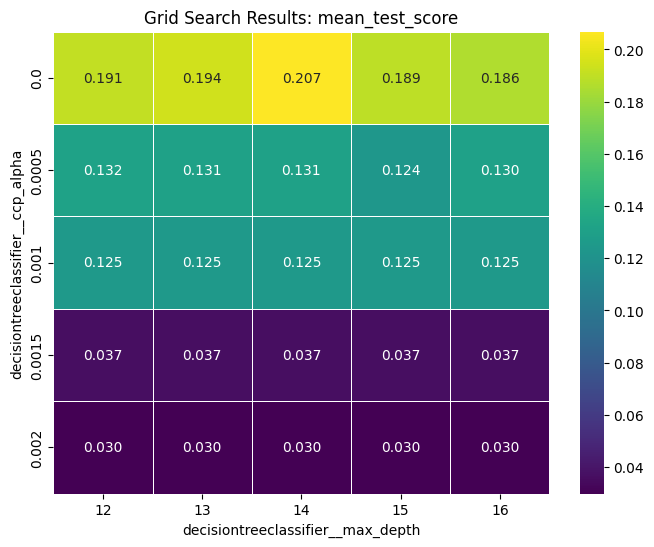

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_gridsearch_heatmap(results_df, x_param, y_param, score='mean_test_score'):    
    # Pivot the table to format it for a heatmap
    heatmap_data = results_df.pivot(index=f'param_{y_param}', columns=f'param_{x_param}', values=score)
    
    # Plot heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(heatmap_data, annot=True, cmap='viridis', fmt='.3f', linewidths=0.5)
    plt.title(f'Grid Search Results: {score}')
    plt.xlabel(x_param)
    plt.ylabel(y_param)
    plt.show()

results = pd.DataFrame(grid_search_dt.cv_results_)
results = results[results['param_' + criterion_key] == 'gini']
plot_gridsearch_heatmap(results, dt_max_depth_key, alpha_key)

In [ ]:
k_fold = KFold(n_splits=10, random_state=1234, shuffle=True)


dt_classifier2 = DecisionTreeClassifier(max_depth=14, ccp_alpha=0.0, criterion="gini", random_state=1234)
dt_pipeline2 = make_pipeline(feature_encoder, scaler, dt_classifier2)

dt_performance, dt_pred = cross_validate_and_predict(
    dt_pipeline2, X_train, y_train, scoring_metrics
)

print(classification_report(y_train, dt_pred))
print(confusion_matrix(y_train, dt_pred))

dt_performance

              precision    recall  f1-score   support

           0       0.96      0.95      0.96      3890
           1       0.18      0.21      0.19       198

    accuracy                           0.92      4088
   macro avg       0.57      0.58      0.57      4088
weighted avg       0.92      0.92      0.92      4088

[[3706  184]
 [ 157   41]]


,fold,accuracy,precision,recall,f1,average_precision
0,1,0.933985,0.230769,0.461538,0.307692,0.123624
1,2,0.926650,0.153846,0.095238,0.117647,0.061107
2,3,0.904645,0.040000,0.062500,0.048780,0.039175
3,4,0.911980,0.181818,0.181818,0.181818,0.077068
4,5,0.887531,0.218750,0.250000,0.233333,0.106032
5,6,0.887531,0.040000,0.043478,0.041667,0.055529
6,7,0.926650,0.277778,0.227273,0.250000,0.104696
7,8,0.902200,0.103448,0.176471,0.130435,0.052485
8,9,0.933824,0.238095,0.312500,0.270270,0.101366
9,10,0.950980,0.500000,0.350000,0.411765,0.206863


## Hyperparameter Tuning (With Oversampling)

Oversampling Model Performance (before tuning)

In [67]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline

oversampler = RandomOverSampler(sampling_strategy="minority", random_state=1234)
oversampled_dt_pipeline = ImbPipeline([("Over Sampler", oversampler), ("DT", dt_pipeline)])

X_train_resampled, y_train_resampled = oversampler.fit_resample(X_train, y_train)

print("Shape of X_train_resampled", X_train_resampled.shape)
print("Number of duplicated instances in X_train_resampled", X_train_resampled.duplicated().sum())
print("Percent of y_train_resampled that is positive class:", y_train_resampled.mean())

oversampled_dt_performance, oversampled_dt_pred = cross_validate_and_predict(
    oversampled_dt_pipeline, X_train, y_train, scoring_metrics
)

print(classification_report(y_train, oversampled_dt_pred))
print(confusion_matrix(y_train, oversampled_dt_pred))

oversampled_dt_performance

Shape of X_train_resampled (7780, 11)
Number of duplicated instances in X_train_resampled 3692
Percent of y_train_resampled that is positive class: 0.5
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      3890
           1       0.17      0.17      0.17       198

    accuracy                           0.92      4088
   macro avg       0.56      0.56      0.56      4088
weighted avg       0.92      0.92      0.92      4088

[[3726  164]
 [ 164   34]]


,fold,accuracy,precision,recall,f1,average_precision
0,1,0.948655,0.250000,0.307692,0.275862,0.098928
1,2,0.904645,0.090909,0.095238,0.093023,0.055113
2,3,0.924205,0.142857,0.187500,0.162162,0.058571
3,4,0.921760,0.250000,0.227273,0.238095,0.098383
4,5,0.887531,0.090909,0.071429,0.080000,0.070063
5,6,0.902200,0.160000,0.173913,0.166667,0.074281
6,7,0.929095,0.266667,0.181818,0.216216,0.092495
7,8,0.914425,0.125000,0.176471,0.146341,0.056289
8,9,0.931373,0.166667,0.187500,0.176471,0.063113
9,10,0.933824,0.266667,0.200000,0.228571,0.092549


Tune Hyperparameters

In [110]:
from sklearn.model_selection import StratifiedKFold

strat_k_fold = StratifiedKFold(n_splits=10, shuffle=True, random_state=1234)


dt_pipeline_name = oversampled_dt_pipeline.steps[1][0]
dt_classifier_name = oversampled_dt_pipeline.steps[1][1].steps[2][0]
step_prefix = '__'
over_dt_step_prefix = f"{dt_pipeline_name}{step_prefix}{dt_classifier_name}{step_prefix}"

over_dt_max_depth_key = f"{over_dt_step_prefix}max_depth"
over_alpha_key = f"{over_dt_step_prefix}ccp_alpha"
over_criterion_key = f"{over_dt_step_prefix}criterion"

over_dt_param_grid = {over_dt_max_depth_key: [2, 3, 4, 5, 6], over_alpha_key: [0.001, 0.002, 0.003, 0.004, 0.005], over_criterion_key: ["gini", "entropy"]}
over_grid_search_dt = GridSearchCV(oversampled_dt_pipeline, over_dt_param_grid, cv=strat_k_fold, scoring=f2_score)
over_grid_search_dt.fit(X_train, y_train)


over_grid_search_dt.best_params_

{'DT__decisiontreeclassifier__ccp_alpha': 0.004,
 'DT__decisiontreeclassifier__criterion': 'gini',
 'DT__decisiontreeclassifier__max_depth': 4}

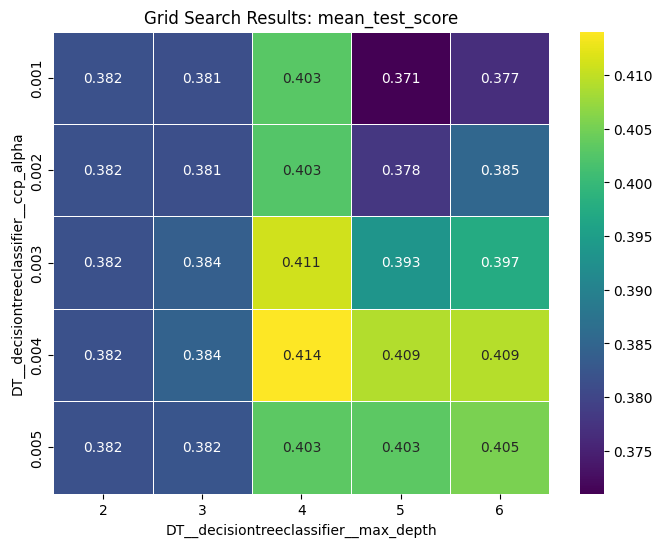

In [111]:
results2 = pd.DataFrame(over_grid_search_dt.cv_results_)
results2 = results2[results2['param_' + over_criterion_key] == 'gini']
plot_gridsearch_heatmap(results2, over_dt_max_depth_key, over_alpha_key)

In [97]:
def stratified_cross_validate_and_predict(model, X_train, y_train, metrics, cv_folds=10, random_state=1234):
    # Convert metrics to functions if they are strings
    metric_fns = [metric if callable(metric) else get_scorer(metric)._score_func for metric in metrics]
    kfold = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    y_preds = np.zeros(y_train.shape)
    results = []
    fold = 1
    for train_idx, test_idx in kfold.split(X_train, y_train):
        model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        y_pred = model.predict(X_train.iloc[test_idx])
        y_preds[test_idx] = y_pred
        fold_results = {'fold': fold}
        for metric_name, metric_fn in zip(metrics, metric_fns):
            value = metric_fn(y_train.iloc[test_idx], y_pred)
            fold_results[metric_name] = value
        results.append(fold_results)
        fold += 1
    return pd.DataFrame(results), y_preds

### Final (Tuned) Training Performance

In [124]:
dt_classifier3 = DecisionTreeClassifier(max_depth=4, ccp_alpha=0.004, criterion="gini", random_state=1234)
dt_pipeline3 = make_pipeline(feature_encoder, scaler, dt_classifier3)

oversampler = RandomOverSampler(sampling_strategy="minority", random_state=1234)
oversampled_dt_pipeline = ImbPipeline([("Over Sampler", oversampler), ("DT", dt_pipeline3)])

X_train_resampled, y_train_resampled = oversampler.fit_resample(X_train, y_train)

print("Shape of X_train_resampled", X_train_resampled.shape)
print("Number of duplicated instances in X_train_resampled", X_train_resampled.duplicated().sum())
print("Percent of y_train_resampled that is positive class:", y_train_resampled.mean())

oversampled_dt_performance, oversampled_dt_pred = stratified_cross_validate_and_predict(
    oversampled_dt_pipeline, X_train, y_train, scoring_metrics
)

print(classification_report(y_train, oversampled_dt_pred))
print(confusion_matrix(y_train, oversampled_dt_pred))

#print(oversampled_dt_performance)
report = classification_report(y_train, oversampled_dt_pred, output_dict=True)
f2_score_0 = (5)/((4 * pow(report["0"]["recall"], -1) + pow(report["0"]["precision"], -1)))
f2_score_1 = (5)/((4 * pow(report["1"]["recall"], -1) + pow(report["1"]["precision"], -1)))

print("f2-Score (0):  ", f2_score_0)
print("f2-Score (1):  ", f2_score_1)

Shape of X_train_resampled (7780, 11)
Number of duplicated instances in X_train_resampled 3692
Percent of y_train_resampled that is positive class: 0.5
              precision    recall  f1-score   support

           0       0.99      0.76      0.86      3890
           1       0.14      0.78      0.24       198

    accuracy                           0.76      4088
   macro avg       0.56      0.77      0.55      4088
weighted avg       0.94      0.76      0.83      4088

[[2951  939]
 [  43  155]]
f2-Score (0):   0.7952463080737306
f2-Score (1):   0.41092258748674443


### Final Test Performance

In [125]:
eval_metric_fns = [metric if callable(metric) else get_scorer(metric)._score_func for metric in scoring_metrics]
oversampled_dt_pipeline.fit(X_train, y_train)
y_predictions = oversampled_dt_pipeline.predict(X_test)
results = {}
for metric_name, metric_fn in zip(scoring_metrics, eval_metric_fns):
    value = metric_fn(y_test, y_predictions)
    results[metric_name] = value
#eval_performance = pd.DataFrame(results)

print(classification_report(y_test, y_predictions))
print(confusion_matrix(y_test, y_predictions))

eval_report = classification_report(y_test, y_predictions, output_dict=True)
f2_score_0 = (5)/((4 * pow(eval_report["0"]["recall"], -1) + pow(eval_report["0"]["precision"], -1)))
f2_score_1 = (5)/((4 * pow(eval_report["1"]["recall"], -1) + pow(eval_report["1"]["precision"], -1)))

print("f2-Score (0):  ", f2_score_0)
print("f2-Score (1):  ", f2_score_1)

              precision    recall  f1-score   support

           0       0.98      0.82      0.89       971
           1       0.15      0.61      0.24        51

    accuracy                           0.81      1022
   macro avg       0.56      0.71      0.56      1022
weighted avg       0.93      0.81      0.86      1022

[[793 178]
 [ 20  31]]
f2-Score (0):   0.8441558441558442
f2-Score (1):   0.37530266343825663
